In [67]:
import pandas as pd
df = pd.read_csv('healthcare_data_cleaning_dataset.csv')
df.head(2)

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23


**Q1. Missing Data Identification**

**Scenario:**
 **The hospital suspects incomplete patient records.**

**Task:**

**Identify missing values in each column**

**Calculate percentage of missing data**

In [11]:
#Identify missing values in each column
df.isnull().sum()

Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64

In [13]:
#Calculate percentage of missing data
((df.isnull().sum()/len(df))*100).round(2)

Patient_ID             0.00
Age                   11.76
Gender                 0.00
City                   0.00
Diagnosis              0.00
Hospital_Visits        0.00
Treatment_Cost        11.63
Insurance_Coverage     0.00
Admission_Date         0.00
dtype: float64

**Q2. Handling Missing Age**

**Scenario:**
 **Age is critical for medical analysis, but some values are missing.**

**Task:**

**Replace missing Age values with an appropriate method**

**Justify your choice (mean/median)**

In [14]:
df['Age'] = df['Age'].fillna(df['Age'].median())


I used median imputation for Age because medical data is typically skewed and may contain outliers. Median is robust and better represents the central tendency without being influenced by extreme values.

**Q3. Handling Missing Treatment Cost**

**Scenario:**
**Treatment cost is highly skewed due to expensive treatments.**

**Task:**

**Handle missing Treatment_Cost values**

**Choose the correct imputation method and explain why**

In [17]:
df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())

Since Treatment_Cost has some very high values, the data is uneven. So I used the median to fill missing values because it is not affected by extreme values. The mean could give a higher, misleading value, but the median gives a more realistic estimate.

**Q4. Duplicate Patient Records**

**Scenario:**
 **Some patient records were entered multiple times.**

**Task:**

**Identify duplicate rows**

**Remove duplicates**

**Compare dataset size before and after**

In [31]:
before = len(df)

In [26]:
#Identify duplicate rows
duplicates = df.duplicated().sum()

In [32]:
#Remove duplicates
df = df.drop_duplicates()

In [28]:
after = len(df)

In [29]:
print("Duplicates:",duplicates)
print("Before:",before)
print("After:",after)

Duplicates: 99
Before: 5100
After: 5001


**Q5. Invalid Age Values (Data Quality Check)**

**Scenario:**
 **Some patients have unrealistic age values (e.g., >100 or <0).**

**Task:**

**Detect such records**

**Decide whether to remove or correct them**

In [41]:
invalid_age = df[(df['Age'] < 0) | (df['Age'] > 100)]
invalid_age


,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date


The dataset was checked for invalid age values such as ages less than 0 or greater than 100. No such records were found, indicating that the Age column does not contain unrealistic values. Therefore, no removal or correction was required.

In [ ]:
df = df[(df['Age'] >= 0) & (df['Age'] <= 100)]

Although no invalid age values were found, the filtering step was still applied to ensure that only valid age ranges (0–100) are retained.

**Q6. Outlier Detection (Treatment Cost)**

**Scenario:**
**Extreme treatment costs are affecting analysis.**

**Task:**

**Detect outliers using IQR method**

**Display number of outliers**

In [51]:
q1 = df['Treatment_Cost'].quantile(0.25)
q3 = df['Treatment_Cost'].quantile(0.75)

IQR = q3 -q1
outliers = df[(df['Treatment_Cost'] < q1-1.5*IQR) | (df['Treatment_Cost'] > q3+1.5*IQR)]
len(outliers)

50

**Q7. Outlier Treatment**

**Scenario:**
**The business team wants to retain all records.**

**Task:**

**Apply capping (Winsorization) on Treatment_Cost**

**Use 5th and 95th percentile**

In [54]:
lower_bound = df['Treatment_Cost'].quantile(0.05)
upper_bound = df['Treatment_Cost'].quantile(0.95)

df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower_bound, upper_bound)


**Q8. Transformation**

**Scenario:**
 **Treatment cost is highly skewed.**

**Task:**

**Apply log transformation**

**Create a new column**

**Compare before vs after distribution**

In [55]:
import numpy as np

df['Log_Treatment_Cost'] = np.log(df['Treatment_Cost'])

<Axes: >

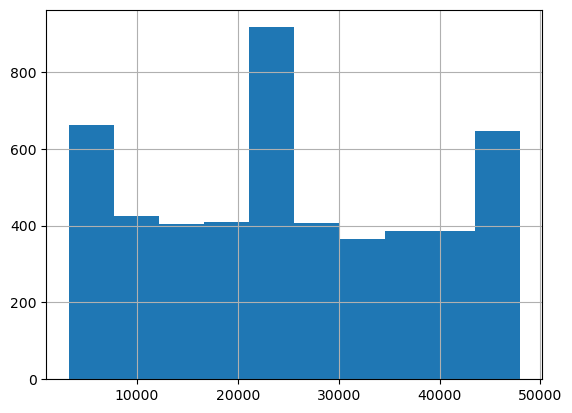

In [56]:
df['Treatment_Cost'].hist()

<Axes: >

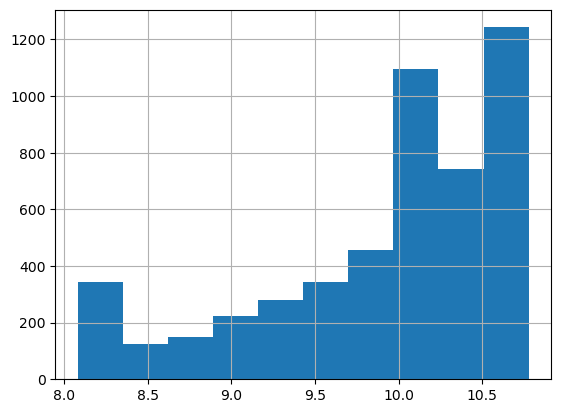

In [57]:
df['Log_Treatment_Cost'].hist()

In [58]:
df['Treatment_Cost'].skew()

np.float64(0.05543898196772683)

In [59]:
df['Log_Treatment_Cost'].skew()

np.float64(-1.0350048510873369)

Since the original data was already nearly symmetric, applying log transformation introduced left skewness. This shows that transformations should be applied only when required, not blindly.

**Q9. Time-Based Missing Handling**

**Scenario:**
 **Admission dates should follow a logical sequence.**

**Task:**

**Sort data by Admission_Date**

**Apply forward fill or backward fill where appropriate**

**Justify your choice**

In [65]:
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])
df = df.sort_values('Admission_Date')
df['Treatment_Cost'] = df['Treatment_Cost'].ffill()

FFill ensures that values follow a logical sequence over time, and helps maintain that by using the most recent known value.